In [1]:
!pip install numpy==1.26.4 scipy==1.12.0 opencv-python==4.9.0.80 mediapipe==0.10.14

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
  Attempting uninstall: opencv-contrib-python
    F

In [2]:
# Install required libraries
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import requests

# Kaggle-compatible image display function (replaces cv2_imshow from Colab)
def cv2_imshow(image):
    """Display image using matplotlib (Kaggle-compatible replacement for cv2_imshow)"""
    if len(image.shape) == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        image_rgb = image
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

def mediapipe_detection(image,model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Color conversion from BGR to RGB
    image.flags.writeable = False                   # Image is no longer writeable
    results = model.process(image)                  # Make prediction
    image.flags.writeable = True                    # Image is no longer writeable
    image = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)   # Color conversion RGB to BGR
    return image, results

def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)  # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)    # Draw right connections

def draw_styled_landmarks(image,results):

    # Draw pose connection
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0,0,255), thickness=1,circle_radius=1),
                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1,circle_radius=1)
                              )
    # Draw left hand connection
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0,0,255), thickness=1,circle_radius=2),
                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1,circle_radius=1)
                              )
    # Draw right hand connection
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0,0,255), thickness=1,circle_radius=2),
                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1,circle_radius=1)
                              )

def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    return np.concatenate([pose, lh, rh])

2026-01-07 11:06:53.366484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767784013.597244      14 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767784013.664508      14 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def detect_hand_landmarks(image_path):
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        # Load the image using OpenCV
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Make detections
        image, results = mediapipe_detection(image, holistic)

        # Draw landmarks to the frame
        draw_styled_landmarks(image,results)

        # Convert the image back to BGR for OpenCV
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Display the image with hand landmarks
        cv2_imshow(image)

In [4]:
# Load preprocessed data from Kaggle dataset
# Dataset: https://www.kaggle.com/datasets/equinnyip/hand-sign-gestures-3
# Specify the path to the preprocessed dataset
dataset_path = '/kaggle/input/hand-sign-gestures-3'

# Get gesture names from the dataset directory structure
# Adjust this path based on the actual structure of the preprocessed dataset
if os.path.exists(dataset_path):
    gestures_files = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    # gestures_files = ['pergi','tidur','bas','sekolah','panas','pandai_2','emak','arah','buat','pinjam','ayah','teksi','bawa','jumpa','lupa','suka','jahat','bomba','lelaki','masa','makan','kacau','sampai','ambil','baca','baik','sejuk','masalah','jam','pensil','kafeteria','keretapi','mari_2','mari','polis','tandas','hospital','panas_2','perlahan_2','perempuan','jalan']
    gestures = np.array(sorted(gestures_files))

print(f"Number of gestures: {len(gestures)}")
print(f"Gestures: {gestures}")

Number of gestures: 90
Gestures: ['abang' 'ada' 'ambil' 'anak_lelaki' 'anak_perempuan' 'apa' 'apa_khabar'
 'arah' 'assalamualaikum' 'ayah' 'baca' 'bagaimana' 'bahasa_isyarat'
 'baik' 'baik_2' 'bapa' 'bapa_saudara' 'bas' 'bawa' 'beli' 'beli_2'
 'berapa' 'berjalan' 'berlari' 'bila' 'bola' 'boleh' 'bomba' 'buang'
 'buat' 'curi' 'dapat' 'dari' 'emak' 'emak_saudara' 'hari' 'hi' 'hujan'
 'jahat' 'jam' 'jangan' 'jumpa' 'kacau' 'kakak' 'keluarga' 'kereta'
 'kesakitan' 'lelaki' 'lemak' 'lupa' 'main' 'makan' 'mana' 'marah' 'mari'
 'masa' 'masalah' 'minum' 'mohon' 'nasi' 'nasi_lemak' 'panas' 'panas_2'
 'pandai' 'pandai_2' 'payung' 'pen' 'pensil' 'perempuan' 'pergi' 'pergi_2'
 'perlahan' 'perlahan_2' 'pinjam' 'polis' 'pukul' 'ribut' 'sampai'
 'saudara' 'sejuk' 'sekolah' 'siapa' 'sudah' 'suka' 'tandas' 'tanya'
 'teh_tarik' 'teksi' 'tidur' 'tolong']


In [5]:
# Load preprocessed data from Kaggle dataset
# Dataset structure: /kaggle/input/hand-sign-gestures-3/{gesture}/landmarks{video_name}/{frame_number}.npy
# Example: /kaggle/input/hand-sign-gestures-3/abang/landmarksabang_1_1_1.mp4/22.npy

label_map = {label: num for num, label in enumerate(gestures)}
gesture_sequence = []
labels = []

for gs in gestures:
    gesture_dir = os.path.join(dataset_path, gs)
    if not os.path.exists(gesture_dir):
        print(f"Warning: Gesture directory {gesture_dir} does not exist, skipping...")
        continue
    
    # Find all landmark subdirectories (folders starting with "landmarks")
    landmark_folders = [fname for fname in os.listdir(gesture_dir) 
                       if os.path.isdir(os.path.join(gesture_dir, fname)) and fname.startswith('landmarks')]
    
    for landmark_folder in landmark_folders:
        load_path = os.path.join(gesture_dir, landmark_folder)
        
        # Get all .npy files and sort them numerically
        npy_files = [f for f in os.listdir(load_path) if f.endswith('.npy')]
        npy_files.sort(key=lambda f: int(''.join(filter(str.isdigit, f))) if any(c.isdigit() for c in f) else 0)
        
        # Load all frames for this video sequence
        video = []
        for npy_file in npy_files:
            keypoints = np.load(os.path.join(load_path, npy_file))
            video.append(keypoints)
        
        # Only add sequences that have at least one frame
        if len(video) > 0:
            gesture_sequence.append(video)
            labels.append(label_map[gs])
            print(f"Loaded: {gs}/{landmark_folder} - {len(video)} frames")

# Calculate the maximum sequence length across all videos
if len(gesture_sequence) > 0:
    max_len = max(len(seq) for seq in gesture_sequence)
    feature_dim = gesture_sequence[0][0].shape[0]  # Get feature dimension from first frame
    
    # Pad shorter sequences with zeros to match the maximum length
    padded_sequences = []
    for seq in gesture_sequence:
        padded_seq = seq + [np.zeros(feature_dim)] * (max_len - len(seq))
        padded_sequences.append(padded_seq)
    
    X = np.array(padded_sequences)
    y = np.array(labels)
    
    print(f"\nData loaded successfully!")
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    print(f"Number of sequences: {len(X)}, Sequence length: {max_len}, Features per frame: {feature_dim}")
else:
    raise FileNotFoundError(f"Could not find any preprocessed data in {dataset_path}. Please check the dataset structure.")

Loaded: abang/landmarksabang_1_2_2.mp4 - 30 frames
Loaded: abang/landmarksabang_4_3_3.mp4 - 30 frames
Loaded: abang/landmarksabang_1_2_3.mp4 - 30 frames
Loaded: abang/landmarksabang_1_5_2.mp4 - 30 frames
Loaded: abang/landmarksabang_4_3_1.mp4 - 30 frames
Loaded: abang/landmarksabang_2_3_1.mp4 - 30 frames
Loaded: abang/landmarksabang_1_5_3.mp4 - 30 frames
Loaded: abang/landmarksabang_4_3_2.mp4 - 30 frames
Loaded: abang/landmarksabang_2_6_3.mp4 - 30 frames
Loaded: abang/landmarksabang_2_1_2.mp4 - 30 frames
Loaded: abang/landmarksabang_2_5_1.mp4 - 30 frames
Loaded: abang/landmarksabang_3_5_3.mp4 - 30 frames
Loaded: abang/landmarksabang_4_4_2.mp4 - 30 frames
Loaded: abang/landmarksabang_1_1_3.mp4 - 30 frames
Loaded: abang/landmarksabang_4_6_2.mp4 - 30 frames
Loaded: abang/landmarksabang_2_2_3.mp4 - 30 frames
Loaded: abang/landmarksabang_3_6_3.mp4 - 30 frames
Loaded: abang/landmarksabang_3_2_1.mp4 - 30 frames
Loaded: abang/landmarksabang_4_1_1.mp4 - 30 frames
Loaded: abang/landmarksabang_3_

In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [7]:
label_map = {label: num for num, label in enumerate(gestures)}
len(label_map)

90

In [8]:
# Data is already loaded in the previous cell
# Verify the data shapes
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Number of samples: {len(X)}, Number of classes: {len(gestures)}")

X shape: (5685, 30, 258), y shape: (5685,)
Number of samples: 5685, Number of classes: 90


In [9]:
# Convert the labels into a one-hot encoded format for classification
# For example, if there are 3 classes, label 1 becomes [0, 1, 0], label 2 becomes [0, 0, 1], etc.
# y is already loaded from the dataset, but we need to ensure it's in the right format
# If y is already one-hot encoded, use it directly; otherwise convert it
if len(y.shape) == 1:
    # y is categorical labels, convert to one-hot
    labels = y  # Keep original labels for stratify
    y = to_categorical(y).astype(int)
else:
    # y is already one-hot encoded, extract original labels for stratify
    labels = np.argmax(y, axis=1)

# Stratified split to preserve class balance; 10% test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=labels,
    random_state=42,
)
print(f"Train: X {X_train.shape}, y {y_train.shape}; Test: X {X_test.shape}, y {y_test.shape}")

Train: X (5116, 30, 258), y (5116, 90); Test: X (569, 30, 258), y (569, 90)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [11]:
# Import f1_score for evaluation metrics
from sklearn.metrics import f1_score

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert numpy arrays to tensors for DataLoader use
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_idx = torch.tensor(y_train.argmax(axis=1), dtype=torch.long)
y_test_idx = torch.tensor(y_test.argmax(axis=1), dtype=torch.long)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_tensor, y_train_idx),
    batch_size=32,
    shuffle=True,
)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test_tensor, y_test_idx),
    batch_size=32,
    shuffle=False,
)

# CNN-LSTM Hybrid Model based on IEEE 11048208
# CNN extracts local spatial-temporal patterns, LSTM captures long-term dependencies
class CNNLSTMHybrid(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.4):
        super(CNNLSTMHybrid, self).__init__()
        
        # 1D CNN layers to extract local patterns from keypoint sequences
        # Conv1d works on (batch, channels, length) - we'll transpose input
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.dropout_cnn = nn.Dropout(dropout)
        
        # LSTM layers to capture temporal dependencies
        # Input size is 128 (from CNN output), hidden size 256
        self.lstm1 = nn.LSTM(128, 256, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(512, 128, batch_first=True, bidirectional=True)  # 512 = 256*2 (bidirectional)
        self.dropout_lstm = nn.Dropout(dropout)
        
        # Fully connected layers for classification
        # 256 = 128*2 (bidirectional LSTM output)
        self.fc1 = nn.Linear(256, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout_fc = nn.Dropout(dropout)
        self.output_layer = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (batch, timesteps, features) -> (batch, features, timesteps) for Conv1d
        x = x.transpose(1, 2)
        
        # CNN feature extraction with residual-like connections
        x1 = torch.relu(self.bn1(self.conv1(x)))
        x2 = torch.relu(self.bn2(self.conv2(x1)))
        x3 = torch.relu(self.bn3(self.conv3(x2)))
        x_cnn = self.dropout_cnn(x3)
        
        # Transpose back: (batch, channels, timesteps) -> (batch, timesteps, channels)
        x_cnn = x_cnn.transpose(1, 2)
        
        # LSTM for temporal modeling
        lstm_out1, _ = self.lstm1(x_cnn)
        lstm_out1 = self.dropout_lstm(lstm_out1)
        lstm_out2, (h_n, _) = self.lstm2(lstm_out1)
        lstm_out2 = self.dropout_lstm(lstm_out2)
        
        # Use the last hidden state from bidirectional LSTM
        # h_n shape: (2, batch, hidden) -> (batch, 2*hidden)
        h_n = h_n.transpose(0, 1).contiguous().view(h_n.size(1), -1)
        
        # Fully connected layers
        x = torch.relu(self.bn_fc(self.fc1(h_n)))
        x = self.dropout_fc(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout_fc(x)
        x = self.output_layer(x)
        
        return x

input_size = 258
num_classes = len(gestures)
model = CNNLSTMHybrid(input_size, num_classes).to(device)
print(f"Model initialized with {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

num_epochs = 200
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    scheduler.step()
    avg_train_loss = running_loss / len(train_loader.dataset)
    loss_history.append(avg_train_loss)

    if (epoch + 1) % 10 == 0:
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                val_loss += criterion(outputs, yb).item() * xb.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
        avg_val_loss = val_loss / len(test_loader.dataset)
        val_acc = correct / total if total else 0
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        print(f"Epoch {epoch+1:03d}/{num_epochs} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

# Final evaluation on test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    val_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        val_loss += criterion(outputs, yb).item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    avg_val_loss = val_loss / len(test_loader.dataset)
    val_acc = correct / total if total else 0
    test_f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Test Loss: {avg_val_loss:.4f} | Test Accuracy: {val_acc:.4f} | Test F1 Score: {test_f1:.4f}")

Model initialized with 1792410 trainable parameters
Epoch 010/200 | train_loss=1.9860 | val_loss=1.6288 | val_acc=0.5149 | val_f1=0.4842
Epoch 020/200 | train_loss=1.1982 | val_loss=0.8148 | val_acc=0.7452 | val_f1=0.7323
Epoch 030/200 | train_loss=0.8498 | val_loss=0.6863 | val_acc=0.8102 | val_f1=0.7996
Epoch 040/200 | train_loss=0.5460 | val_loss=0.4514 | val_acc=0.8418 | val_f1=0.8356
Epoch 050/200 | train_loss=0.4497 | val_loss=0.4691 | val_acc=0.8647 | val_f1=0.8519
Epoch 060/200 | train_loss=0.2475 | val_loss=0.2489 | val_acc=0.9262 | val_f1=0.9227
Epoch 070/200 | train_loss=0.2229 | val_loss=0.3718 | val_acc=0.8910 | val_f1=0.8871
Epoch 080/200 | train_loss=0.2178 | val_loss=0.2419 | val_acc=0.9262 | val_f1=0.9252
Epoch 090/200 | train_loss=0.1734 | val_loss=0.2545 | val_acc=0.9350 | val_f1=0.9350
Epoch 100/200 | train_loss=0.1577 | val_loss=0.1834 | val_acc=0.9350 | val_f1=0.9327
Epoch 110/200 | train_loss=0.1168 | val_loss=0.2034 | val_acc=0.9473 | val_f1=0.9472
Epoch 120/200

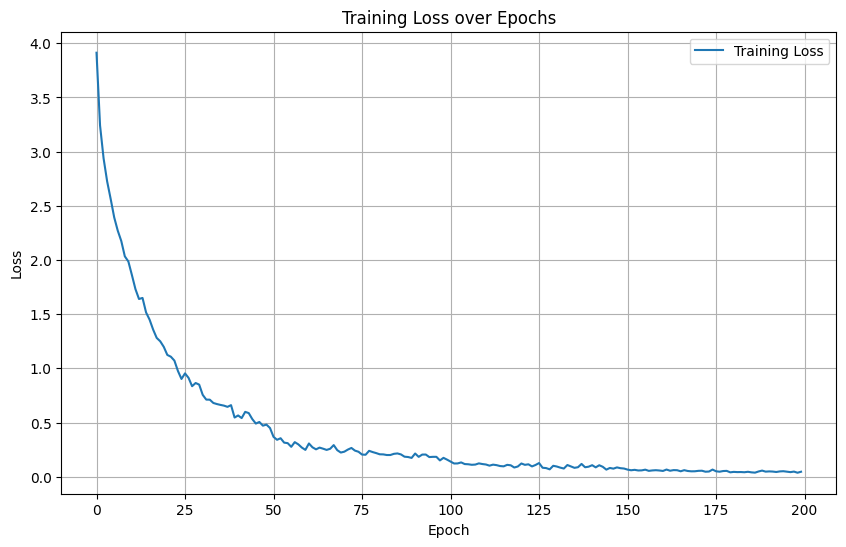

In [12]:
# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Save the trained model
model_filename = 'trained_model.pth'
torch.save(model.state_dict(), model_filename)
print(f"Model saved as {model_filename}")

Model saved as trained_model.pth


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import pandas as pd  # Add this line

Confusion Matrix:
[[7 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 6]]


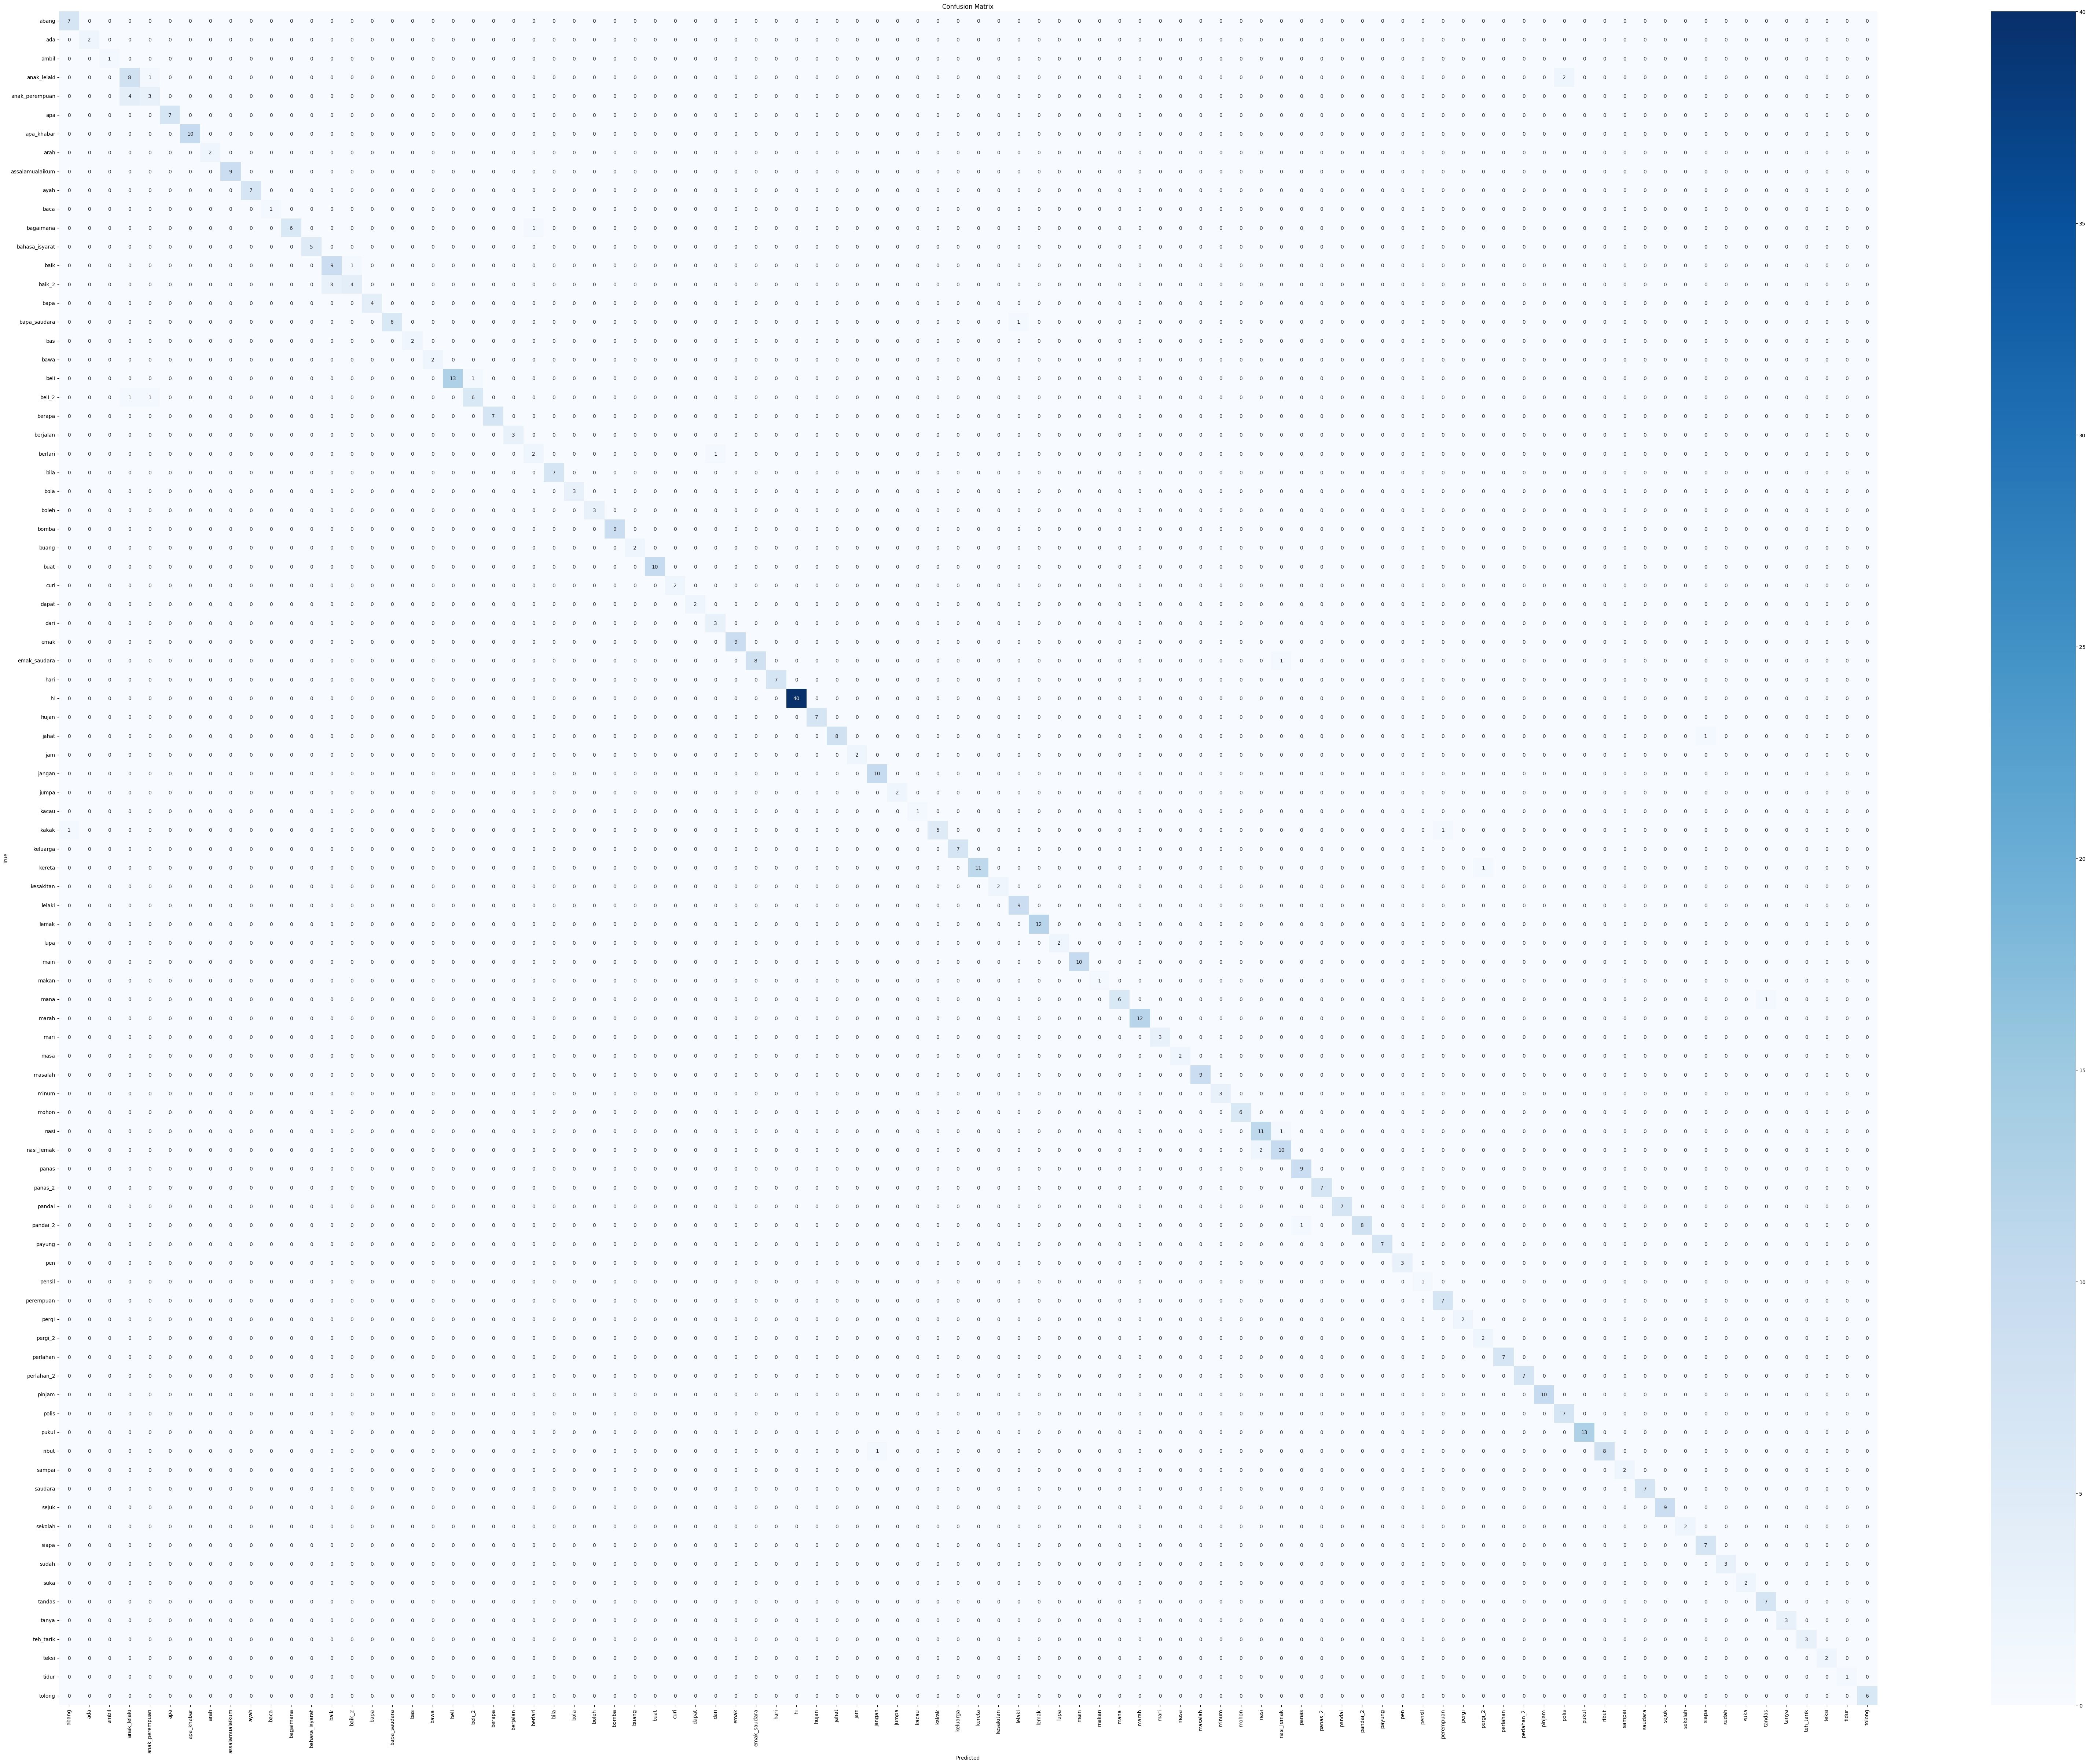

Classification Report:
                 precision    recall  f1-score   support

          abang       0.88      1.00      0.93         7
            ada       1.00      1.00      1.00         2
          ambil       1.00      1.00      1.00         1
    anak_lelaki       0.62      0.73      0.67        11
 anak_perempuan       0.60      0.43      0.50         7
            apa       1.00      1.00      1.00         7
     apa_khabar       1.00      1.00      1.00        10
           arah       1.00      1.00      1.00         2
assalamualaikum       1.00      1.00      1.00         9
           ayah       1.00      1.00      1.00         7
           baca       1.00      1.00      1.00         1
      bagaimana       1.00      0.86      0.92         7
 bahasa_isyarat       1.00      1.00      1.00         5
           baik       0.75      0.90      0.82        10
         baik_2       0.80      0.57      0.67         7
           bapa       1.00      1.00      1.00         4
   bapa

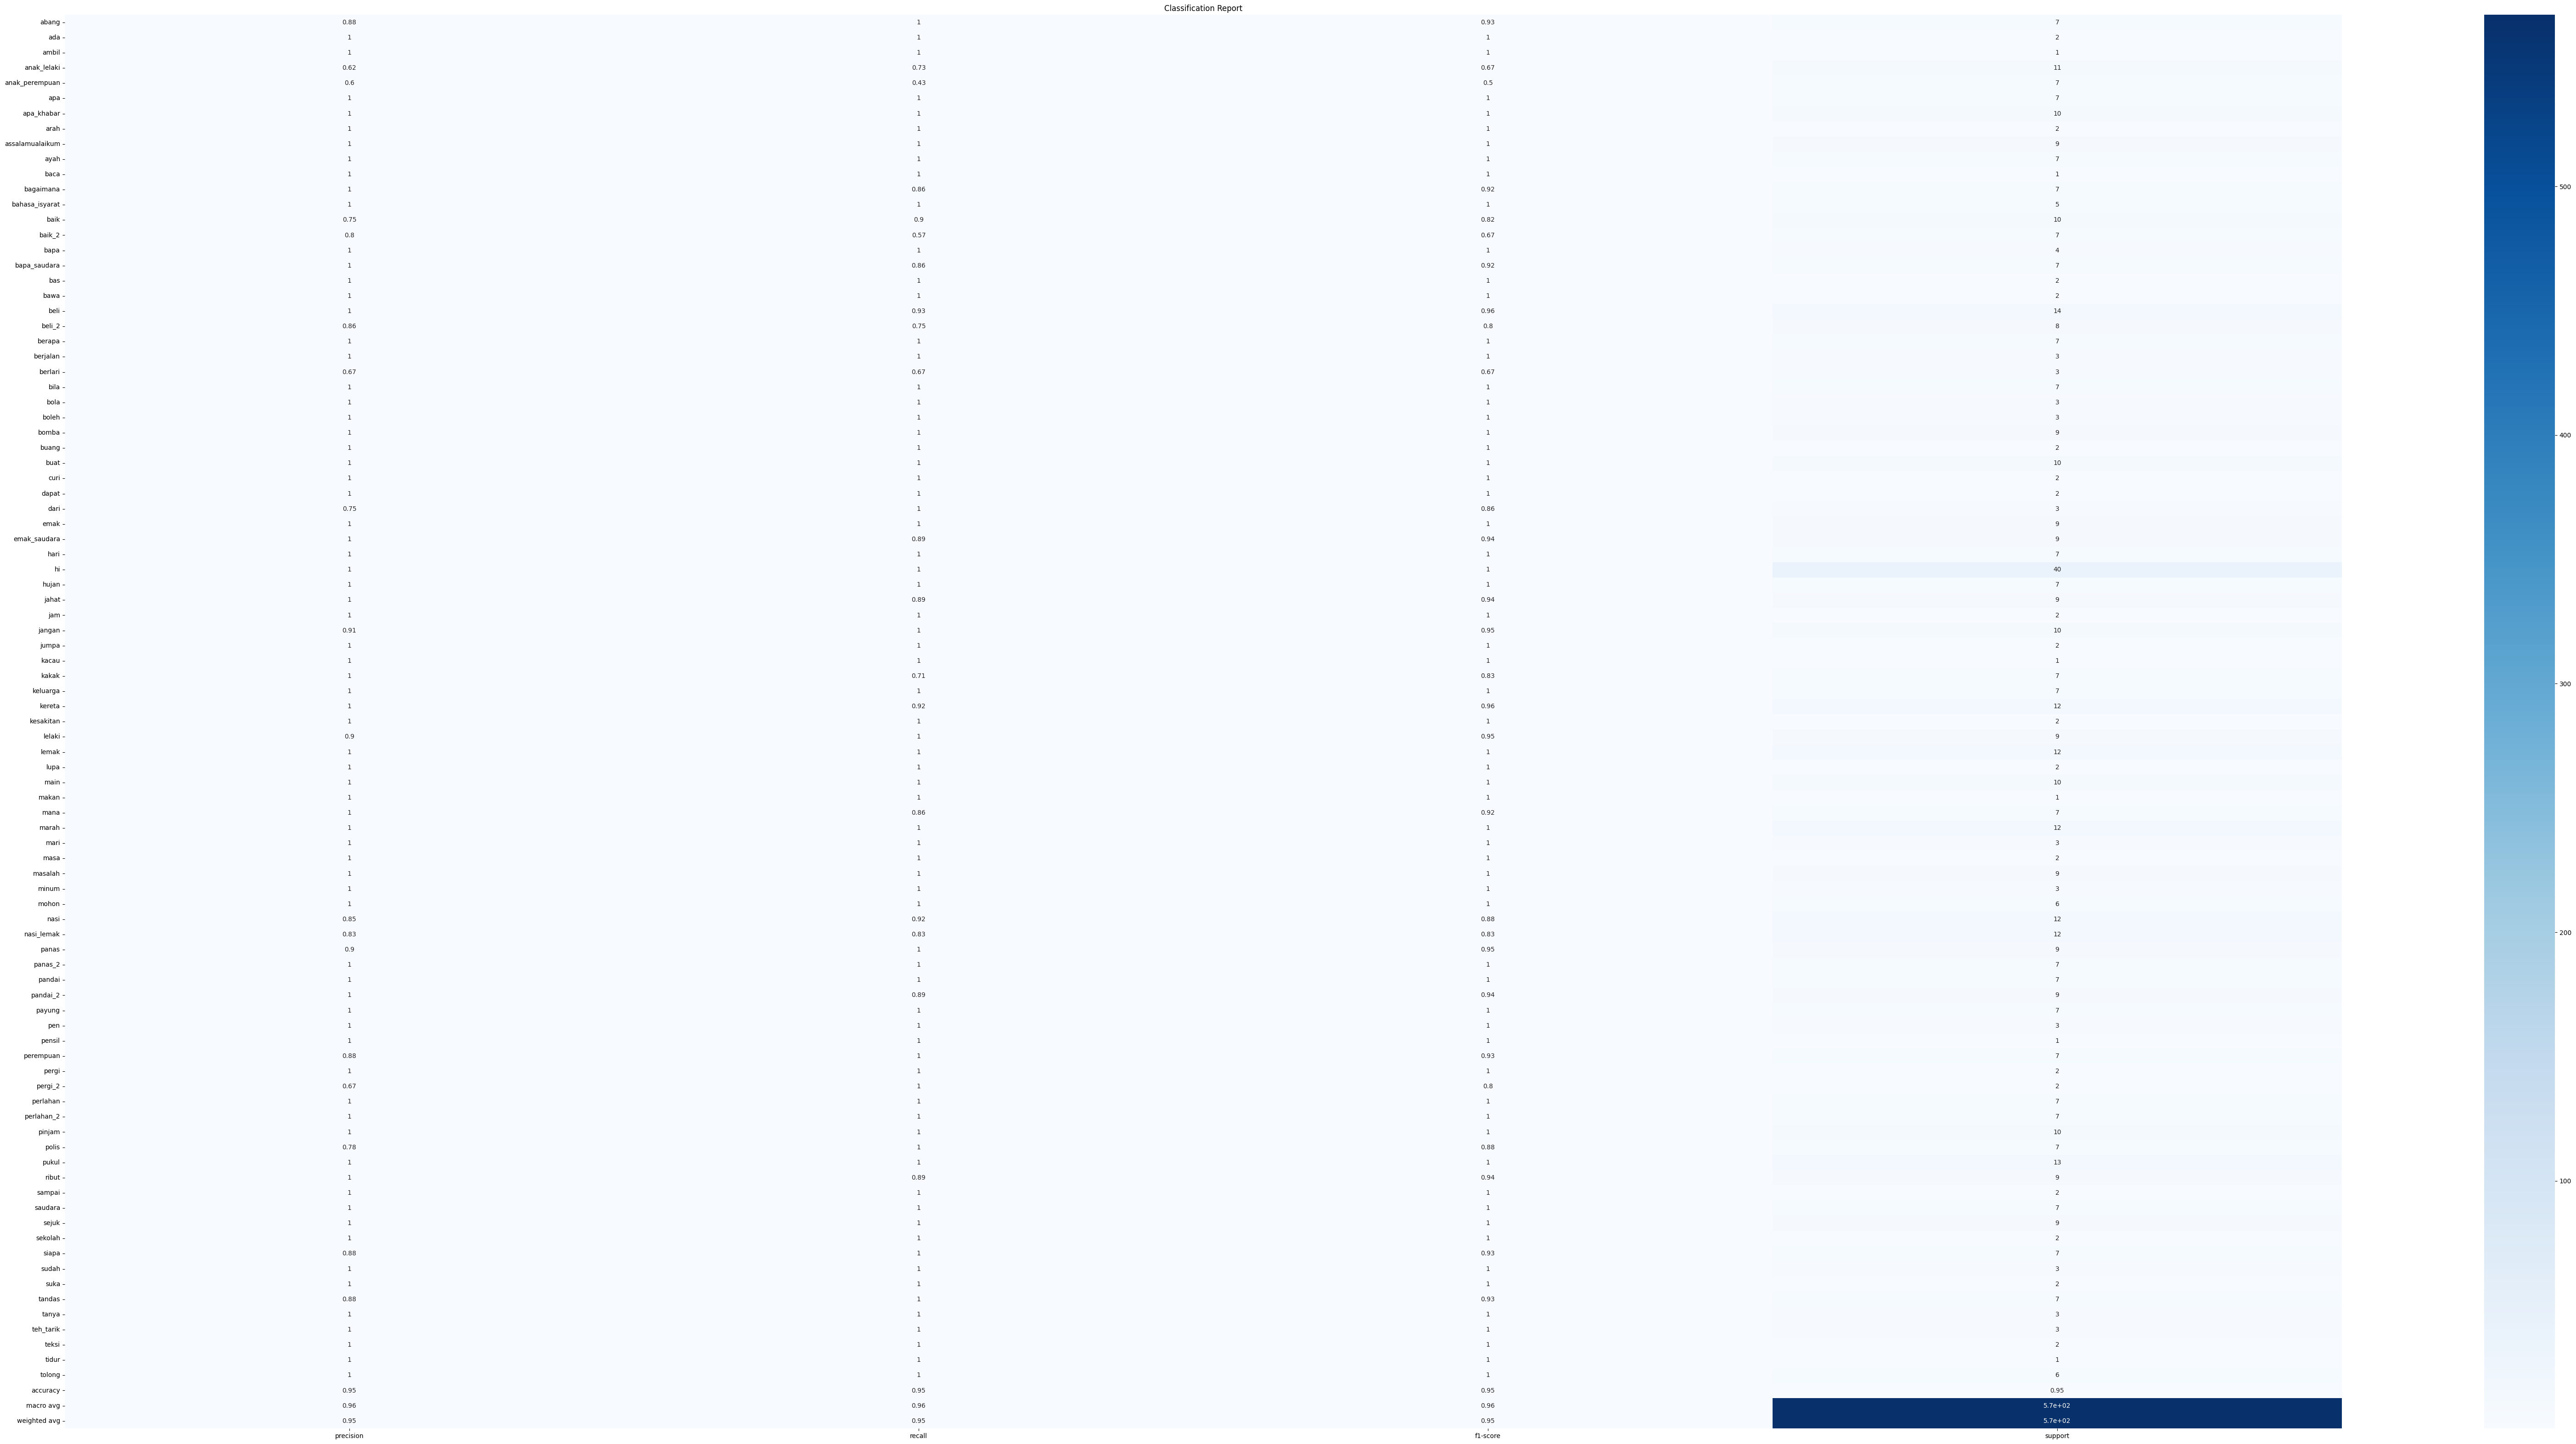

In [15]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        all_preds.append(outputs.argmax(dim=1))
        all_labels.append(yb)

    predicted_labels = torch.cat(all_preds).cpu().numpy()
    true_labels = torch.cat(all_labels).cpu().numpy()

    # Determine the labels actually present in predictions/ground truth
    unique_labels = np.unique(np.concatenate([true_labels, predicted_labels]))

    # Map labels to names when available; fallback to string ids
    if 'gestures' in globals():
        label_names = []
        for lbl in unique_labels:
            if lbl < len(gestures):
                label_names.append(gestures[lbl])
            else:
                label_names.append(str(lbl))
    else:
        label_names = [str(lbl) for lbl in unique_labels]

    # Calculate and print the confusion matrix using consistent label ordering
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=unique_labels)
    print("Confusion Matrix:")
    print(conf_matrix)

    # Plot the confusion matrix with aligned tick labels
    plt.figure(figsize=(80, 60))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Calculate and print the classification report with matching label names
    class_report = classification_report(true_labels, predicted_labels, labels=unique_labels, target_names=label_names)
    print("Classification Report:")
    print(class_report)
    
    # Calculate and display F1 scores
    f1_macro = f1_score(true_labels, predicted_labels, average='macro')
    f1_weighted = f1_score(true_labels, predicted_labels, average='weighted')
    f1_micro = f1_score(true_labels, predicted_labels, average='micro')
    print(f"\nF1 Scores:")
    print(f"  Macro F1: {f1_macro:.4f}")
    print(f"  Weighted F1: {f1_weighted:.4f}")
    print(f"  Micro F1: {f1_micro:.4f}")

    # Plot the classification report
    plt.figure(figsize=(80, 40))
    report_df = pd.DataFrame.from_dict(classification_report(true_labels, predicted_labels, labels=unique_labels, target_names=label_names, output_dict=True)).T
    sns.heatmap(report_df, annot=True, cmap='Blues')
    plt.title('Classification Report')
    plt.show()

In [16]:
# CNN-LSTM Hybrid Model (same as training)
class CNNLSTMHybrid(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.4):
        super(CNNLSTMHybrid, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout_cnn = nn.Dropout(dropout)
        self.lstm1 = nn.LSTM(128, 256, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(512, 128, batch_first=True, bidirectional=True)
        self.dropout_lstm = nn.Dropout(dropout)
        self.fc1 = nn.Linear(256, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout_fc = nn.Dropout(dropout)
        self.output_layer = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        x1 = torch.relu(self.bn1(self.conv1(x)))
        x2 = torch.relu(self.bn2(self.conv2(x1)))
        x3 = torch.relu(self.bn3(self.conv3(x2)))
        x_cnn = self.dropout_cnn(x3)
        x_cnn = x_cnn.transpose(1, 2)
        lstm_out1, _ = self.lstm1(x_cnn)
        lstm_out1 = self.dropout_lstm(lstm_out1)
        lstm_out2, (h_n, _) = self.lstm2(lstm_out1)
        lstm_out2 = self.dropout_lstm(lstm_out2)
        h_n = h_n.transpose(0, 1).contiguous().view(h_n.size(1), -1)
        x = torch.relu(self.bn_fc(self.fc1(h_n)))
        x = self.dropout_fc(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout_fc(x)
        x = self.output_layer(x)
        return x

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
input_size = 258
num_classes = len(gestures)
model = CNNLSTMHybrid(input_size, num_classes)

# Load the saved model state dictionary
model_filename = 'trained_model.pth'
loaded_model_state_dict = torch.load(model_filename, map_location='cpu')

# Load the state dictionary into the model
model.load_state_dict(loaded_model_state_dict)
model.to(device)  # Move model to the same device as the input tensors
model.eval()  # Set the model to evaluation mode

# Generate colors dynamically based on number of gestures
def generate_colors(n):
    """Generate n distinct colors for visualization"""
    colors = []
    for i in range(n):
        # Use HSV color space for better color distribution
        hue = int(180 * i / n)  # Hue from 0 to 180 (OpenCV uses 0-180 for HSV)
        # Create a bright, saturated color
        color_hsv = np.uint8([[[hue, 255, 255]]])
        color_bgr = cv2.cvtColor(color_hsv, cv2.COLOR_HSV2BGR)[0][0]
        colors.append(tuple(map(int, color_bgr)))
    return colors

colors = generate_colors(len(gestures))

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    # Limit display to top 10 gestures by probability to avoid overcrowding
    if len(res) > 10:
        # Get top 10 indices sorted by probability
        top_indices = np.argsort(res)[-10:][::-1]
        top_probs = res[top_indices]
        top_actions = actions[top_indices]
        top_colors = [colors[i] for i in top_indices]
    else:
        top_indices = range(len(res))
        top_probs = res
        top_actions = actions
        top_colors = colors
    
    # Draw probability bars
    bar_height = 30
    bar_spacing = 5
    start_y = 60
    
    for num, (prob, action, color) in enumerate(zip(top_probs, top_actions, top_colors)):
        y_pos = start_y + num * (bar_height + bar_spacing)
        bar_width = int(prob * 200)  # Scale to 200 pixels max width
        
        # Draw background rectangle
        cv2.rectangle(output_frame, (0, y_pos), (200, y_pos + bar_height), (50, 50, 50), -1)
        # Draw probability bar
        cv2.rectangle(output_frame, (0, y_pos), (bar_width, y_pos + bar_height), color, -1)
        # Draw text
        cv2.putText(output_frame, f'{action}: {prob:.2%}', (5, y_pos + 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    return output_frame

def get_shape(data):
    if not isinstance(data, list):
        return ()
    return (len(data),) + get_shape(data[0])

# 1. New detection variables
sequence = []
sentence = []
predictions = []

# Replace 'video.mp4' with the path to your video file
cap = cv2.VideoCapture('/kaggle/input/hand-sign-gestures-3/abang/landmarksabang_1_1_2.mp4')

# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        # Read feed
        ret, frame = cap.read()

        # Exit loop if video ends
        if not ret:
            break

        # Make detections
        image, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        # Initialize prediction display variables
        predicted_gesture = "Waiting..."
        confidence = 0.0
        probs_np = np.zeros(len(gestures))

        if results.left_hand_landmarks or results.right_hand_landmarks:
            if len(sequence) == 30:
                # Move tensor to the same device as the model
                sequence_tensor = torch.tensor(np.expand_dims(sequence, axis=0), dtype=torch.float32).to(device)
                res = model(sequence_tensor)
                
                # Convert logits to probabilities using softmax
                probabilities = torch.nn.functional.softmax(res, dim=1)
                max_val, max_idx = torch.max(probabilities, dim=1)
                
                # Store prediction
                predictions.append(max_idx.item())
                
                # Keep only last 5 predictions for sentence display
                if len(predictions) > 5:
                    predictions = predictions[-5:]
                
                # Update sentence if we have consistent predictions
                if len(predictions) >= 3:
                    # Check if last 3 predictions are the same
                    if len(set(predictions[-3:])) == 1:
                        if len(sentence) == 0 or sentence[-1] != gestures[predictions[-1]]:
                            sentence.append(gestures[predictions[-1]])
                            sentence = sentence[-5:]  # Keep last 5 gestures
                
                # Convert probabilities to numpy for visualization
                probs_np = probabilities[0].cpu().detach().numpy()
                
                # Get predicted gesture and confidence
                predicted_gesture = gestures[max_idx.item()]
                confidence = max_val.item()
                
                # Print prediction result (for debugging)
                print(f"Confidence: {confidence:.4f} | Predicted gesture: {predicted_gesture}")
        else:
            # Show status when hands are not detected
            predicted_gesture = "No hands detected"
            confidence = 0.0
        
        # Visualize probabilities (always show, even if zero)
        image = prob_viz(probs_np, gestures, image, colors)
        
        # Draw prediction text on frame
        cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, f'Prediction: {predicted_gesture}', (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        if confidence > 0:
            cv2.putText(image, f'Confidence: {confidence:.2%}', (400, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Display sequence status
        cv2.putText(image, f'Sequence: {len(sequence)}/30', (10, image.shape[0] - 80), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Display sentence (sequence of detected gestures)
        if len(sentence) > 0:
            sentence_text = ' '.join(sentence)
            cv2.rectangle(image, (0, image.shape[0] - 60), (640, image.shape[0]), (245, 117, 16), -1)
            cv2.putText(image, f'Sentence: {sentence_text}', (10, image.shape[0] - 20), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Display the frame
        cv2_imshow(image)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1767790421.849846      74 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767790421.873050      74 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767790421.875175      77 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767790421.876140      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767790421.876660      74 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767790421.886633     